In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel


In [12]:
train_df = pd.read_csv('train_data.csv')
val_df = pd.read_csv('val_data.csv')

label = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\n|\r|\t", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df['clean'] = train_df['comment_text'].apply(clean_text)
val_df['clean'] = val_df['comment_text'].apply(clean_text)


In [13]:
print(train_df.shape)

train_df.head()

(127656, 10)


,Unnamed: 0,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,clean
0,41967,6ff62abb9f08ee3d,And more unfounded personal attacks by here a...,0,0,0,0,0,0,and more unfounded personal attacks by here at...
1,155824,c438cd4e8073254a,Gilmore Girls \n\nI'm trying to figure out a f...,0,0,0,0,0,0,gilmore girls i m trying to figure out a few t...
2,17231,2d7e5045431a4c70,What is the need of tagging..when we can impro...,0,0,0,0,0,0,what is the need of tagging when we can improv...
3,82855,ddb267b1a581c366,"03:27, Jun 23, 2005 (UTC)",0,0,0,0,0,0,03 27 jun 23 2005 utc
4,31322,53252a7f4f4bf87d,Inconsistencies \n\nThis article seems to pick...,0,0,0,0,0,0,inconsistencies this article seems to pick and...


In [14]:
tfidf = TfidfVectorizer()
X_train = tfidf.fit_transform(train_df['clean'])
X_val = tfidf.transform(val_df['clean'])

#train
model = OneVsRestClassifier(LogisticRegression())
model.fit(X_train, train_df[label])

#Scores
y_pred = model.predict(X_val)
print(classification_report(val_df[label], y_pred, target_names=label))

               precision    recall  f1-score   support

        toxic       0.92      0.61      0.73      3059
 severe_toxic       0.61      0.28      0.38       311
      obscene       0.92      0.63      0.75      1710
       threat       0.55      0.11      0.19        97
       insult       0.84      0.52      0.64      1590
identity_hate       0.74      0.20      0.32       289

    micro avg       0.89      0.56      0.68      7056
    macro avg       0.76      0.39      0.50      7056
 weighted avg       0.88      0.56      0.68      7056
  samples avg       0.06      0.05      0.05      7056



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
macro_f1 = f1_score(val_df[label], y_pred, average='macro', zero_division=0)
per_label = f1_score(val_df[label], y_pred, average=None, zero_division=0)

print(f"\nMacro F1: {macro_f1:.4f}\n")
for label, score in zip(label, per_label):
    print(f"  {label:<20} {score:.4f}")


Macro F1: 0.5018

  toxic                0.7326
  severe_toxic         0.3805
  obscene              0.7490
  threat               0.1880
  insult               0.6444
  identity_hate        0.3161



Train Label Distribution
toxic
0    115421
1     12235
Name: count, dtype: int64

Validation Label Distribution
toxic
0    28856
1     3059
Name: count, dtype: int64

Train Percentages
toxic
0    90.415648
1     9.584352
Name: proportion, dtype: float64

Validation Percentages
toxic
0    90.415165
1     9.584835
Name: proportion, dtype: float64


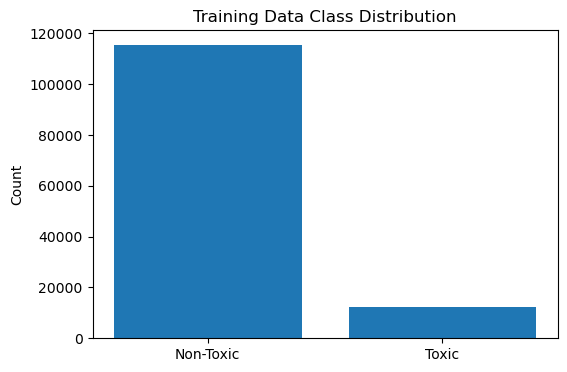

In [18]:
train_counts = train_df['toxic'].value_counts()
val_counts = val_df['toxic'].value_counts()

print("\nTrain Label Distribution")
print(train_counts)

print("\nValidation Label Distribution")
print(val_counts)

# Percentages
train_percent = train_df['toxic'].value_counts(normalize=True) * 100
val_percent = val_df['toxic'].value_counts(normalize=True) * 100

print("\nTrain Percentages")
print(train_percent)

print("\nValidation Percentages")
print(val_percent)

# Plot class imbalance
plt.figure(figsize=(6,4))
plt.bar(['Non-Toxic', 'Toxic'], train_counts.values)
plt.ylabel('Count')
plt.title('Training Data Class Distribution')
plt.show()

-- 
Heavily imbalanced data --> may lead to more non-toxic predictions 

In [20]:
# Separate toxic and non-toxic comments
non_toxic_df = train_df[train_df['toxic'] == 0]
toxic_df = train_df[train_df['toxic'] == 1]

# Sample smaller subsets for faster testing
non_toxic_sample = non_toxic_df.sample(5000, random_state=42)
toxic_sample = toxic_df.sample(5000, random_state=42, replace=True)

# Combine text
combined_text = pd.concat([
    non_toxic_sample['comment_text'],
    toxic_sample['comment_text']
])

# TF-IDF
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2)
)


In [22]:
X = vectorizer.fit_transform(combined_text)

# Split vectors
non_toxic_vectors = X[:len(non_toxic_sample)]
toxic_vectors = X[len(non_toxic_sample):]

# Toxic centroid
# Average toxic language direction

toxic_centroid = np.asarray(toxic_vectors.mean(axis=0))

# Similarity scores
scores = cosine_similarity(non_toxic_vectors, toxic_centroid)

# Flatten
scores = scores.flatten()

# Add scores to dataframe
non_toxic_sample = non_toxic_sample.copy()
non_toxic_sample['toxicity_similarity'] = scores

# Most suspicious non-toxic examples
suspicious = non_toxic_sample.sort_values(
    by='toxicity_similarity',
    ascending=False
)

print(suspicious[['comment_text', 'toxicity_similarity']].head(20))

                                             comment_text  toxicity_similarity
78381   "\n\nThe user's final edit was to blank his Ta...             0.260124
118049  "\n\n Hey What's Up \n\nHey Pink Floyd guy,\nI...             0.252102
5675    "noobs...\nI have contested the speedy deletio...             0.236125
75771   "\n\nIsn't it what you ususally say each and e...             0.209940
56111   "\n\nThanks Ral315. I don't know what you enjo...             0.197543
59947   Recent prooves of hetz being made and of the c...             0.195657
74041   "quicker response please email me)\n\n  \nYou ...             0.195517
116140  I dont get it.... you're clearly a bright guy....             0.193896
116009  this guy nailed it on the head! Paralympiakos ...             0.190978
46112   "\n\n Life on Aisle 5 \n\nDo you have a life o...             0.188268
26740   Abuse of admin privileges \n\nI have caught yo...             0.187974
54083   Yes, I am 12 in a half. My apologies before 

In [ ]:
MODEL_NAME = "meta-llama/Llama-3.2-1B"

# Load tokenizer/model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

# Use smaller subsets for speed
non_toxic_subset = non_toxic_df.sample(200, random_state=42)
toxic_subset = toxic_df.sample(200, random_state=42, replace=True)

# Embedding function

def get_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model(**inputs)

    embedding = outputs.last_hidden_state.mean(dim=1)
    return embedding.squeeze().numpy()

# Toxic embeddings
print("Generating toxic embeddings...")

toxic_embeddings = np.array([
    get_embedding(text)
    for text in toxic_subset['comment_text']
])

# Toxic centroid
llama_toxic_centroid = toxic_embeddings.mean(axis=0)

# Non-toxic similarity scores
print("Checking non-toxic comments...")

similarities = []

for text in non_toxic_subset['comment_text']:
    emb = get_embedding(text)

    score = cosine_similarity(
        emb.reshape(1, -1),
        llama_toxic_centroid.reshape(1, -1)
    )[0][0]

    similarities.append(score)

non_toxic_subset = non_toxic_subset.copy()
non_toxic_subset['llama_similarity'] = similarities

# Most suspicious examples
llama_suspicious = non_toxic_subset.sort_values(
    by='llama_similarity',
    ascending=False
)

print(llama_suspicious[['comment_text', 'llama_similarity']].head(20))

OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Llama-3.2-1B.
401 Client Error. (Request ID: Root=1-6a0a9930-305cc2ac4dddca0a4f7ea804;e8155d88-2999-46ee-bcb2-335a3f989c08)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-1B/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-1B is restricted. You must have access to it and be authenticated to access it. Please log in.